In [1]:
import os;
os.listdir('/kaggle/input/')


['employee-income']

In [2]:
import pandas as pd
import numpy as np
# Load dataset
data = pd.read_csv('/kaggle/input/employee-income/employee_income.csv')

In [3]:
# Inspect data
print(data.head())
print(data.columns)
print(data.shape)
print(data.info())

   age  experience  income
0   50           5   45118
1   36           9   41691
2   29           3   35994
3   42           5   41614
4   40          12   51474
Index(['age', 'experience', 'income'], dtype='object')
(50, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB
None


                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     299.6
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           1.78e-27
Time:                        09:01:23   Log-Likelihood:                -447.00
No. Observations:                  50   AIC:                             900.0
Df Residuals:                      47   BIC:                             905.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.946e+04   1245.629     15.623      0.0

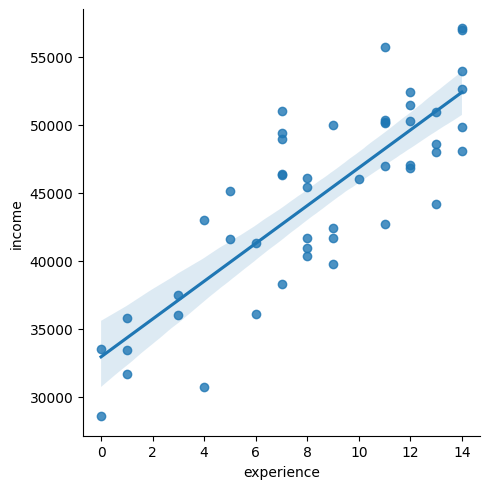

In [4]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

X = data[["age", "experience"]]
X = sm.add_constant(X)  # add a constant to represent bias
y = data["income"]

# build model
model = sm.OLS(y, X).fit()

# print result
print(model.summary())
sns.lmplot(x="experience", y="income", data=data)
plt.show()

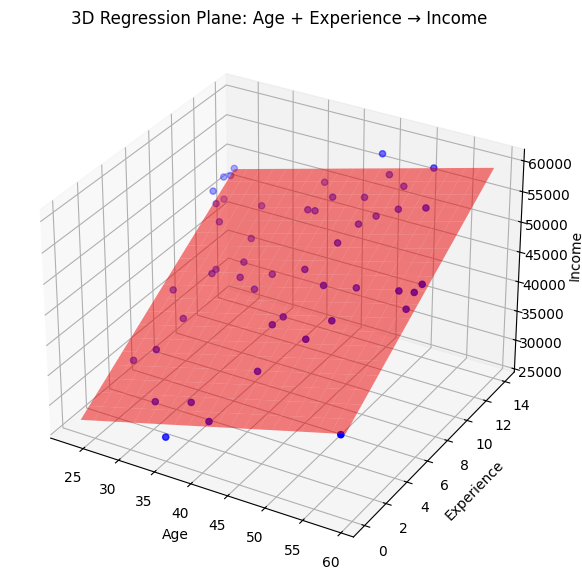

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm


X = data[["age", "experience"]]
X = sm.add_constant(X)  # add constant (bias)
y = data["income"]

# build model
model = sm.OLS(y, X).fit()


b0, b1, b2 = model.params  # const, age, experience


age_range = np.linspace(data["age"].min(), data["age"].max(), 20)
exp_range = np.linspace(data["experience"].min(), data["experience"].max(), 20)
age_grid, exp_grid = np.meshgrid(age_range, exp_range)

# calculate predicted income
income_pred = b0 + b1 * age_grid + b2 * exp_grid

# plot a 3D grapph
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(data["age"], data["experience"], data["income"], color="blue", label="Actual data")

ax.plot_surface(age_grid, exp_grid, income_pred, color="red", alpha=0.5)

ax.set_xlabel("Age")
ax.set_ylabel("Experience")
ax.set_zlabel("Income")
plt.title("3D Regression Plane: Age + Experience → Income")
plt.show()


In [6]:
import pandas as pd

# Example data for five people
# A: 30 years old, 5 years experience
# B: 40 years old, 10 years experience
# C: 35 years old, 8 years experience
# D: 50 years old, 20 years experience
# E: 25 years old, 2 years experience

new_people = pd.DataFrame({
    "const": [1, 1, 1, 1, 1],   # constant column for bias term
    "age": [30, 40, 35, 50, 25],
    "experience": [5, 10, 8, 20, 2]
})

# Predict incomes
pred_incomes = model.predict(new_people)

# Show results
for person, income in zip(["A", "B", "C", "D", "E"], pred_incomes):
    print(f"{person}: Predicted income = {income:.2f}")


A: Predicted income = 36625.70
B: Predicted income = 47369.54
C: Predicted income = 42750.96
D: Predicted income = 65646.78
E: Predicted income = 30500.44


In [7]:
print(data.head())
print(data.columns)
print(data.shape)

   age  experience  income
0   50           5   45118
1   36           9   41691
2   29           3   35994
3   42           5   41614
4   40          12   51474
Index(['age', 'experience', 'income'], dtype='object')
(50, 3)


In [8]:
#Try to do linear regression using Least-square-method and Machine learning

x = data["experience"].values
# Output (target)
y = data["income"].values

# Set initial value
w = 0.0   # w : weights
b = 0.0   # b : bias

def predict(x, w, b):
 y_hat = x * w + b
 return y_hat

def mean_squared_error(y, y_hat):
  loss = ((y_hat - y) **2).mean()
  return loss

In [9]:
def compute_gradients(x, y, y_hat):

  N =len(y)
  # Gradient w.r.t. weight
  dw = (2 / N) * (x * (y_hat - y)).sum()
  # Gradient w.r.t. bias
  db = (2 / N) * (y_hat - y).sum()
  return dw, db

In [10]:
def update_parameters(w, b, dw, db, learn):
  w = w - learn * dw
  b = b - learn * db
  return w, b

In [11]:
learn =0.0001
epochs =500000



In [12]:
for epoch in range(epochs):
 y_hat = predict(x, w, b)
 loss = mean_squared_error(y, y_hat)
 dw, db = compute_gradients(x, y, y_hat)
 w, b = update_parameters(w, b, dw, db, learn)

 if epoch %50000 ==0:
  print(f"Epoch {epoch}, Loss:{loss}")

print(f"Epoch {epoch}, Loss:{loss}")



Epoch 0, Loss:2059668204.9
Epoch 50000, Loss:19856896.950611256
Epoch 100000, Loss:14922478.150288325
Epoch 150000, Loss:14793931.911406256
Epoch 200000, Loss:14790583.161290115
Epoch 250000, Loss:14790495.923208015
Epoch 300000, Loss:14790493.65057414
Epoch 350000, Loss:14790493.591369886
Epoch 400000, Loss:14790493.589827565
Epoch 450000, Loss:14790493.589787388
Epoch 499999, Loss:14790493.58978634


In [13]:
print(w,b)

1390.303658069126 32935.25454263195


In [14]:
#Check answer with statsmodels.api

import pandas as pd
import numpy as np
# Load dataset
data = pd.read_csv('/kaggle/input/employee-income/employee_income.csv')

import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

P = data["experience"]
P = sm.add_constant(P)  # add a constant to represent bias
q = data["income"]

# build model
model = sm.OLS(q, P).fit()

# print result
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     104.2
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           1.30e-13
Time:                        09:01:36   Log-Likelihood:                -483.68
No. Observations:                  50   AIC:                             971.4
Df Residuals:                      48   BIC:                             975.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.294e+04   1293.960     25.453      0.0